# Recovery S, G2/M Trial

### Motivation: 
Here I would like to determine the feasibility and assess the fit and interpretability of creating a model with an independent S and G2M

### Background:
Currently there is a limitation to the model when there is modeling differences during S/G2/M. Because S/G2/M is assumed to be identical in the recovery, mother, and daughter branches, the model attempts to use the free CG1 and RG1 degrees of freedom to best fit the curve creating a disjointed transition in CG1 to S.

### Procedure:
1. Create a new model that defines a postG1 specifically for the recovery branch
2. Create a config that can properly interpret this new model
3. Fit the gene expression of the example scenario in which this occurs
4. Fit the gene expresison for a gene whose S/G2M are identical in recovery and in mother/daughter.
    

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from src.create_models_RSG2M import create_wt1_model, create_wt2_model


In [27]:
alpha = 22
wt1_model_file = f'models/yl_cell_cycle/wt1_r1sg2m.{alpha}.label'
create_wt1_model(wt1_model_file, alpha=alpha)

alpha = 20
wt2_model_file = f'models/yl_cell_cycle/wt2_r1sg2m.{alpha}.label'
create_wt2_model(wt2_model_file, alpha=alpha)


Created model and saved to file: models/yl_cell_cycle/wt1_r1sg2m.22.label
Created model and saved to file: models/yl_cell_cycle/wt2_r1sg2m.20.label


'models/yl_cell_cycle/wt2_r1sg2m.20.label'

In [55]:
from src.recovery_config import load_yl_replicate1_rg1_alpha_vst_config
from src.recovery_config import load_combined_recovery_gene_expression_config
from src.recovery_config import plot_H

combined_config = load_combined_recovery_gene_expression_config()
config = load_yl_replicate1_rg1_alpha_vst_config()
H, hpos = config.calcH_function(config.intervals_wt1, config.WT1_TIMEPOINTS)

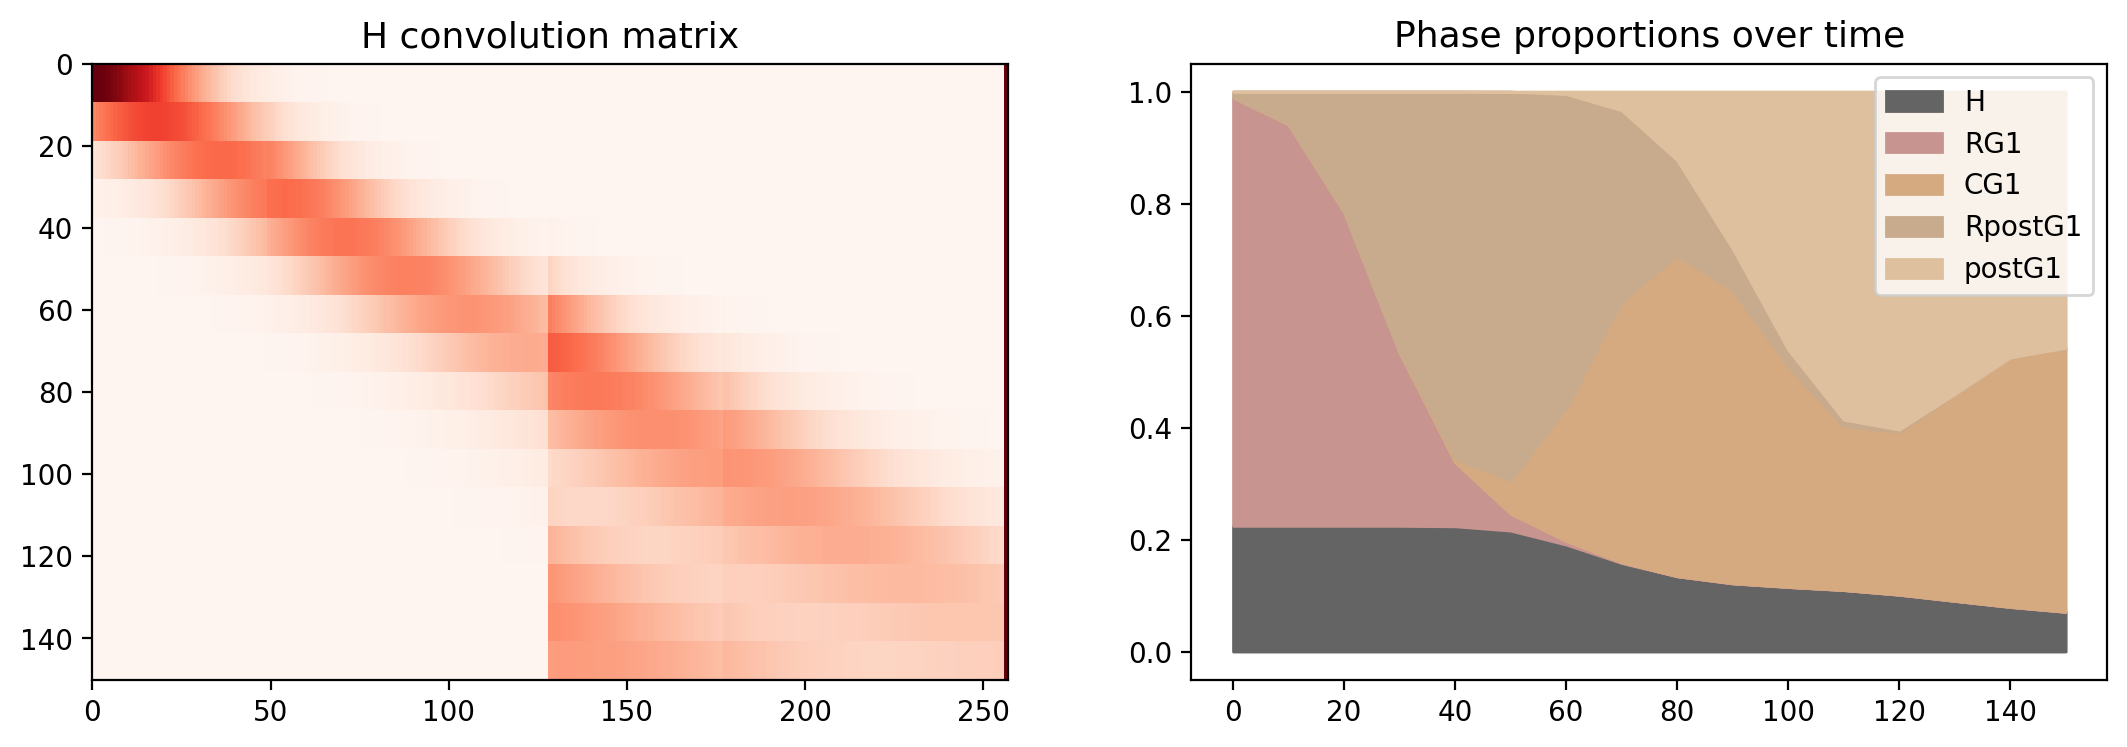

In [54]:
plot_H(config, H)

In [561]:
from src.model import Model

combined_config.copy_correction = None
model = Model(combined_config, 'CLB5')
#model.deconvolve_find_optimal_gamma()
model.gamma = 0.1
model.deconvolve()

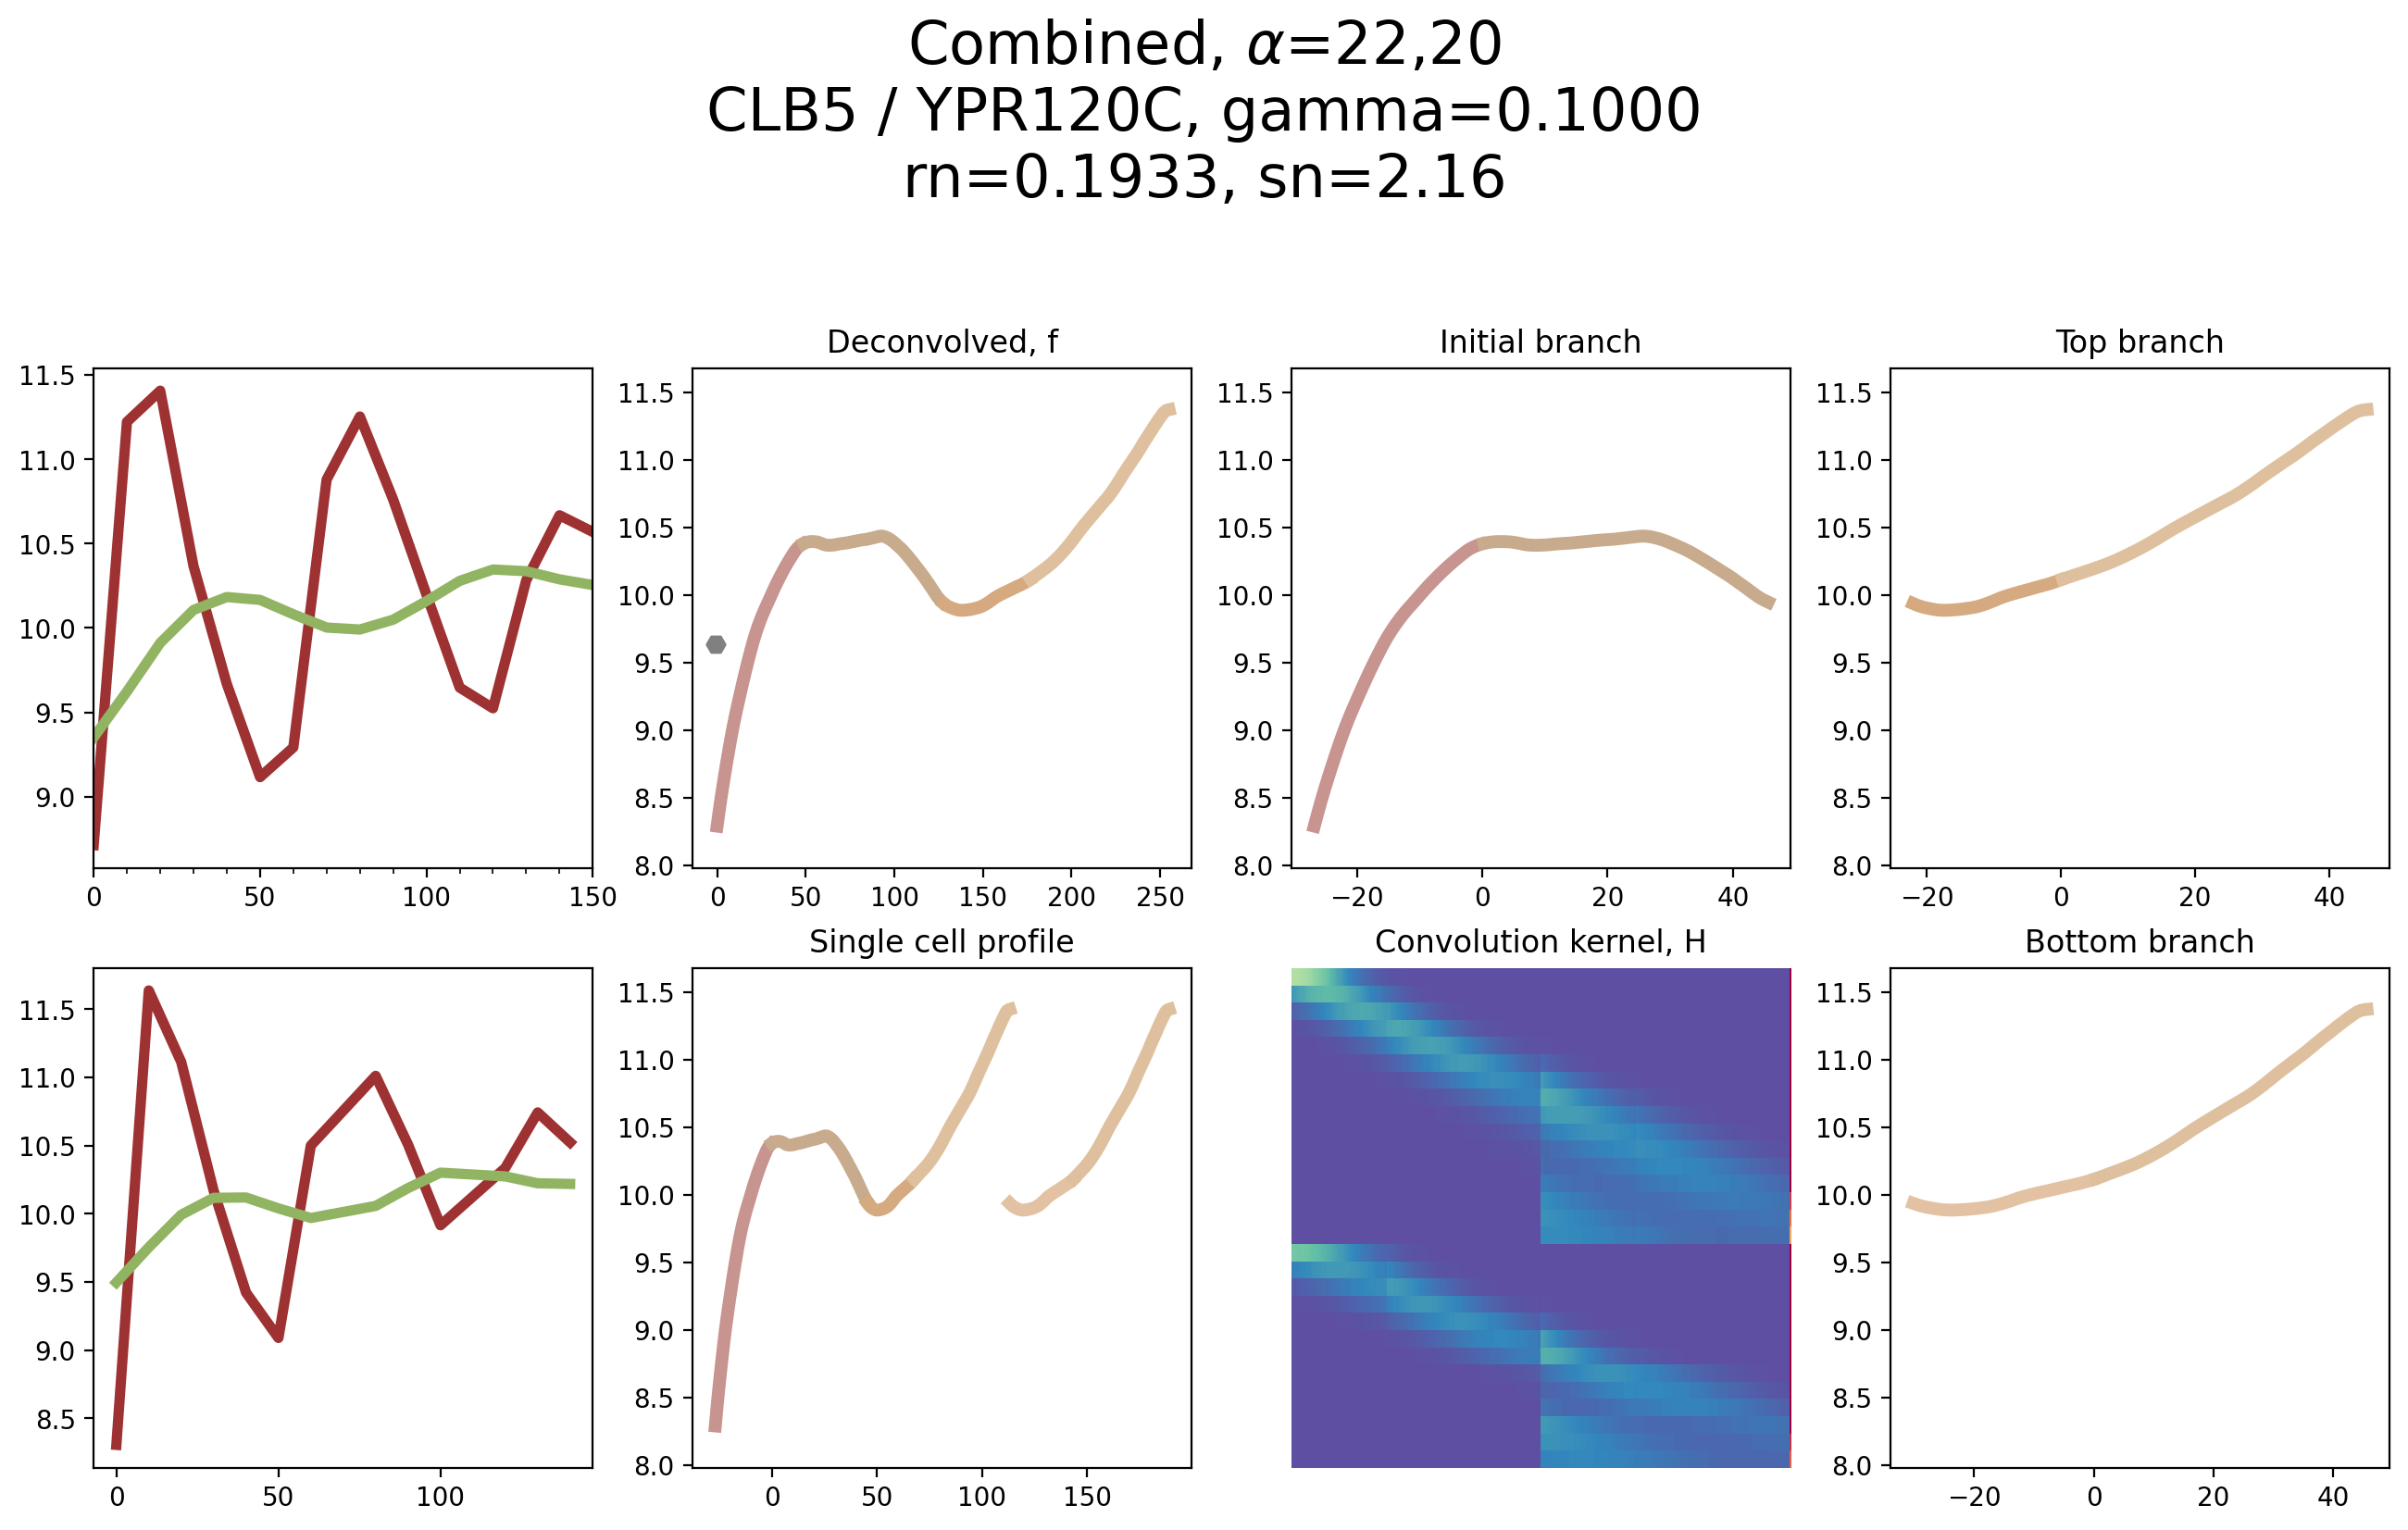

In [562]:
fig = model.plot_deconvolved_gene()

In [140]:
# Is it the mirroring code that needs to be adjusted?

In [144]:
from src.single_G1_config import load_combined_single_g1_gene_expression_config

original_combined_config = load_combined_single_g1_gene_expression_config()

In [793]:
from src.model import Model

original_combined_config.copy_correction = None
model = Model(original_combined_config, 'CLB2')

# Some selected gammas that are predefined: the find gamma curve has some issue
# finding an appropriate smoothing:
# CLB2: 0.02
# CLB5: 0.002
# CLN2: 0.0023

#model.deconvolve_find_optimal_gamma()
model.gamma = 0.02
model.deconvolve()

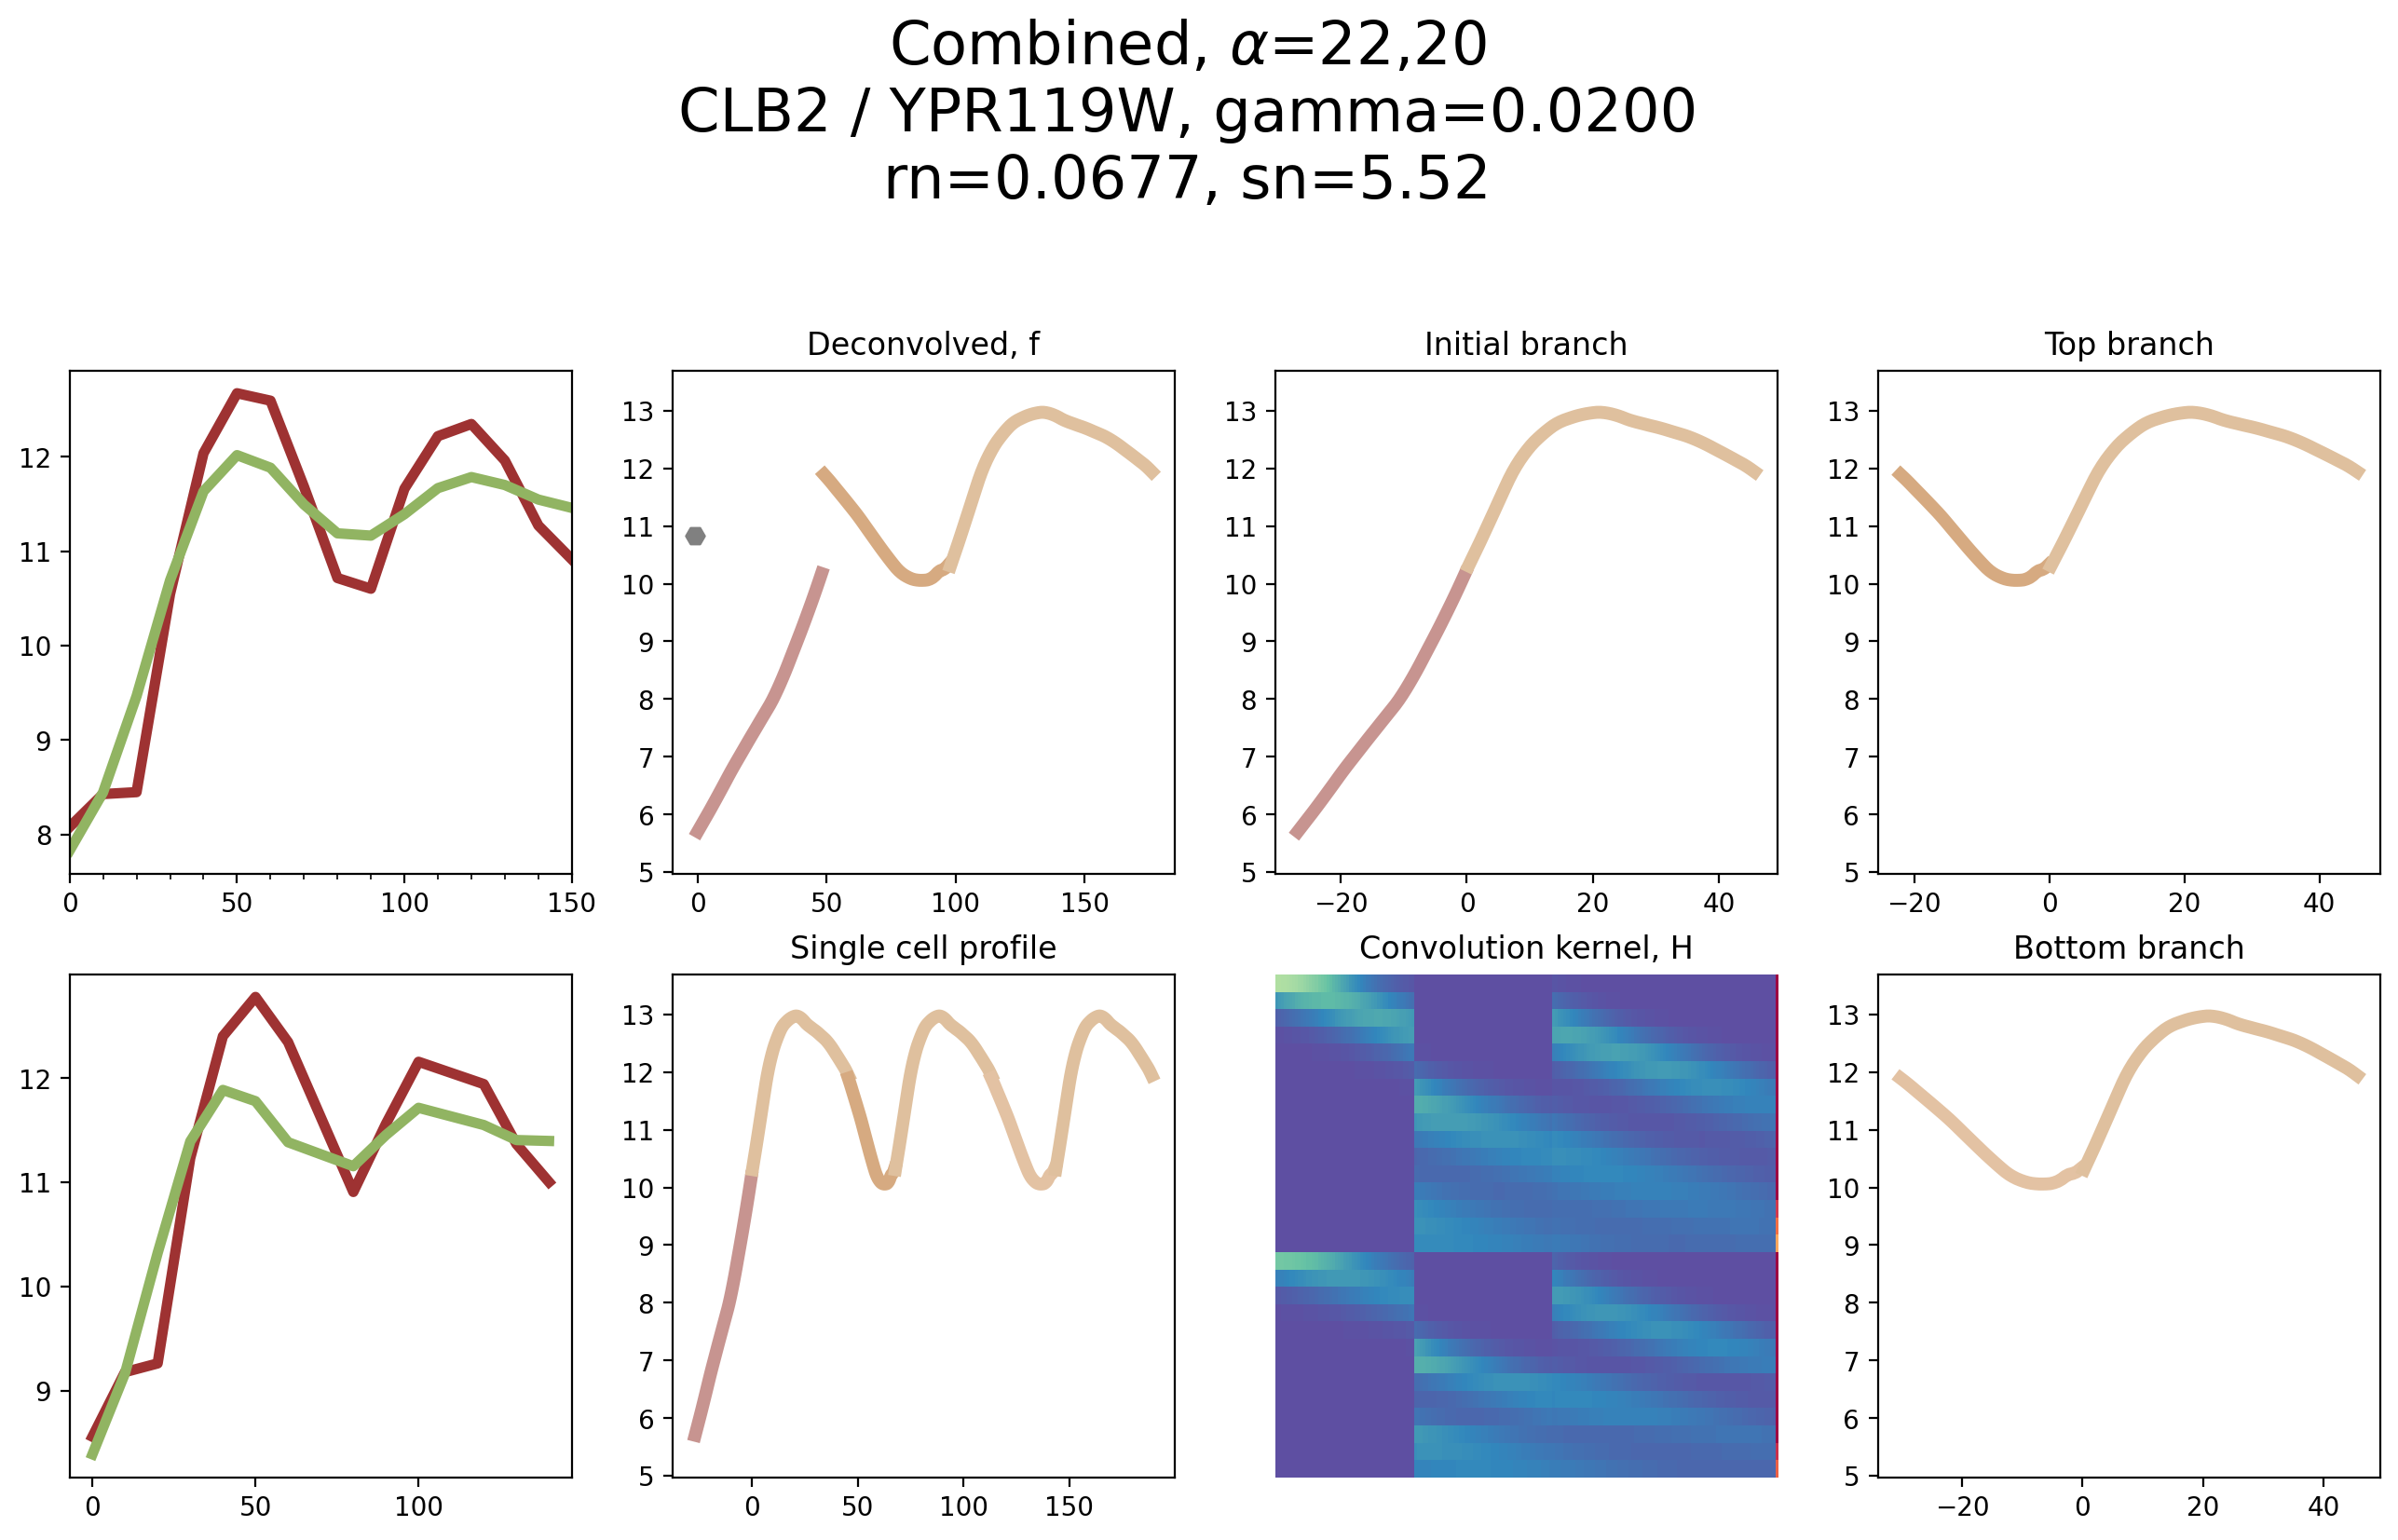

In [794]:
fig = model.plot_deconvolved_gene()

In [565]:
repl_timing = pd.read_csv(
        'data/replication_timing/yl_2019/chrom_replication_timing_shared.csv'
    ).set_index(['chr', 'start']).sort_values('replication_index')

early = repl_timing.iloc[3].name
late = repl_timing.iloc[-3].name
clb2_loc = 16, 770000

early, late, clb2_loc

# Nucleosome summation curve
# Nucleosome entropy curve
# Total occupancy curve
# Typhoon plot, normalize and unnormalized

# Hyperparameters
#
# Padding: None, Left, Both
#
# Gamma: 0.1, 0.2, 0.4
#

# Stick to both padding... it makes the most sense...
test_regions_df = pd.DataFrame([pd.Series(early), pd.Series(late), pd.Series(clb2_loc)])
test_regions_df.columns = ['chr', 'start']
test_regions_df['end'] = test_regions_df['start']+10000
test_regions_df.to_csv('data/reference_data/sacCer3_test_10k_windows.csv')
test_regions_df

,chr,start,end
0,10,194000,204000
1,3,260000,270000
2,16,770000,780000


In [534]:
pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')

,chr,start,end
0,1,0,10000
1,1,10000,20000
2,1,20000,30000
3,1,30000,40000
4,1,40000,50000
...,...,...,...
1211,16,900000,910000
1212,16,910000,920000
1213,16,920000,930000
1214,16,930000,940000
